In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns
#dataset = fetch_california_housing()
#dataset = pd.read_csv(r'C:\Users\Gwanggu-ai-academy-park\boston.csv')

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/boston/boston.csv')

#엑셀로 저장시험문제

df.to_excel("boston.xlsx")


# df.info()
# df.describe()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


최종 인사이트 = 주택가격에 영향을 미치는 요인을 분석하기

데이터구조확인 

In [3]:
# 컬럼명 한글 변환 딕셔너리
col_kr = {
    "CRIM": "범죄율",
    "ZN": "25,000평방피트 이상 주거지 비율",
    "INDUS": "비상업지역 비율",
    "CHAS": "찰스강 인접 여부",
    "NOX": "일산화질소 농도",
    "RM": "평균 방 개수",
    "AGE": "노후 건물 비율",
    "DIS": "고용센터까지 거리",
    "RAD": "고속도로 접근성",
    "TAX": "재산세율",
    "PTRATIO": "학생-교사 비율",
    "B": "흑인 비율 지수",
    "LSTAT": "하위 계층 비율",
    "MEDV": "주택 중간값(집값)"
}

# 컬럼명 변경
df = df.rename(columns=col_kr)

In [12]:
!apt-get update -qq
!apt-get install -y fonts-nanum
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 62 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (64.9 MB/s)    
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

<!-- CRIM	범죄율
     ZN	대지 비율 (25,000 sq.ft 이상)
     INDUS	비상업 지역 비율
     CHAS	강 인접 여부 (1: 인접, 0: 아님)
     NOX	공기 오염도
     RM	평균 방 개수
     AGE	오래된 집 비율
     DIS	직장까지 거리
     RAD	고속도로 접근성
     TAX	재산세율
     PTRATIO	학생-교사 비율
     B	흑인 비율 지표
     LSTAT	저소득층 비율
     MEDV	집값 (타겟값) -->

In [5]:
# 데이터 전처리 및 구조확인
# print(df.columns)
# df.info()
# df.describe().T
# df.isnull().sum()
# df.shape

# ===================인사이트===================
# 총 14 컬럼 에 506 행의 데이터가 있다
# 전부 숫자형 데이터이다
# 결측치가 없다
# 컬럼명을 한글로 분석완료 하였음





단변량/ 기초통계량 확인

In [6]:
## 1) 단변량 분석 및 기초통계량 확인

# 분석
# 1. 범죄율
# 평균적으로 대부분 지역은 범죄율이 없거나 낮다
# 일부지역에 범죄율이 많은곳이 있다
# 평균 과 중앙값의 차이가 많이난다 매우큰 이상치값이 있다고 해석할수있다

# 2. 25,000평방피트 이상 주거지 비율
# df["25,000평방피트 이상 주거지 비율"].describe()
# 중앙값이 0이므로 절반의 지역이 0이다
# 평균과 중앙값 차이가 크다 오른쪽으로 치우친 분포(양의 왜도)
# 일부지역은 주거지비율이 매우 높다

# 3. 비상업지역 비율
# 비교적 최대 최소값이 극단적으로 차이가있지않다

# 4. 찰스강 인접 여부
# df["찰스강 인접 여부"].describe()*100
# 약 7프로 정도만 찰스강과 인접한 지역이다.
# 0과 1만 존재하는 이진형 변수이다.

# 5. 일산화질소 농도
# 비교적 균형적인 분포를 가진다

# 6. 평균 방 개수
# df["평균 방 개수"].describe()
# 가장 정규분포에 가까운 데이터를 가진다
# 지역별 평균 방 개수는 6개이다

# 7. 노후 건물 비율
# df["노후 건물 비율"].describe()
# 평균과 표준편차에 차이가 크다
# 지역별 노후주택비율의 차이가 존재한다

# 8.재산세율
# df["재산세율"].describe()
# 지역별 재산세율 차이가 크다
# 일부 높은 재산율이 평균을 증가시켰다

# 9."주택 중간값(집값)"
# df["주택 중간값(집값)"].describe()
# 평균과 중앙값의 차이가 비슷하다 주택가격은 비교적 균형적인 분포를 보인다
# 일부 고가의 주택이 존재하지만 대부분 25이하에 분포되어있다.

# 10. 하위 계층 비율
# df["하위 계층 비율"].describe()
# 비교적 평균과 중앙값이 큰차이가 없어 균형적인 분포를보인다
# 표준편차 와 평균 차이를 확인해보니 지역별 하위계층비율의 차이가 존재한다
# 최소 최대값 차이를 확인해보니 일부지역에는 하위계층비율이 매우 높으며 이상치가 존재할 가능성이있다
# 로그변환 후에도 일부 높은 값이 존재하지만 원본 데이터보다 왜도가 완화되었다


In [ ]:
# 피처 엔지니어링
# 1.로그변환
df["범죄율"] = np.log1p(df["범죄율"])
df["하위 계층 비율"] = np.log1p(df["하위 계층 비율"])
df["25,000평방피트 이상 주거지 비율"] = np.log1p(df["25,000평방피트 이상 주거지 비율"])


# 2. 평균 방 개수 구간화
df["방개수등급"] = pd.cut(
    df["평균 방 개수"],
    bins=[2,5.5,6.5,9],
    labels=["작음","보통","많음"]
)




array([[<Axes: title={'center': '범죄율'}>,
        <Axes: title={'center': '25,000평방피트 이상 주거지 비율'}>,
        <Axes: title={'center': '비상업지역 비율'}>,
        <Axes: title={'center': '찰스강 인접 여부'}>],
       [<Axes: title={'center': '일산화질소 농도'}>,
        <Axes: title={'center': '평균 방 개수'}>,
        <Axes: title={'center': '노후 건물 비율'}>,
        <Axes: title={'center': '고용센터까지 거리'}>],
       [<Axes: title={'center': '고속도로 접근성'}>,
        <Axes: title={'center': '재산세율'}>,
        <Axes: title={'center': '학생-교사 비율'}>,
        <Axes: title={'center': '흑인 비율 지수'}>],
       [<Axes: title={'center': '하위 계층 비율'}>,
        <Axes: title={'center': '주택 중간값(집값)'}>, <Axes: >, <Axes: >]],
      dtype=object)

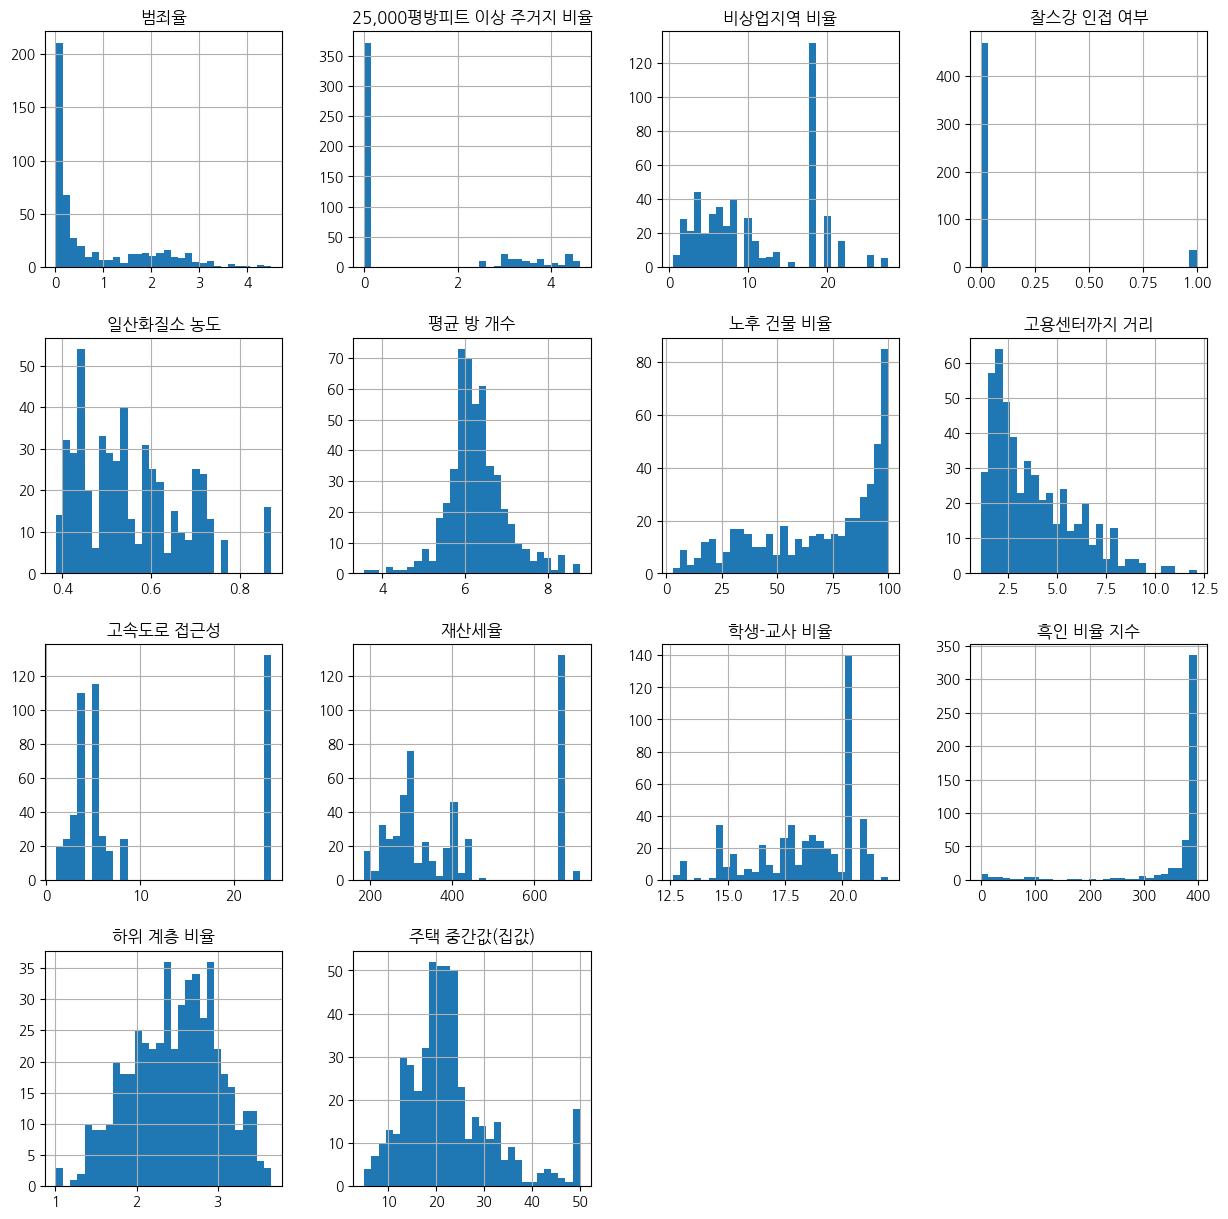

In [8]:

df.hist(figsize=(15, 15), bins=30)

상관관계 분석

In [9]:
corr = df.corr(numeric_only=True)

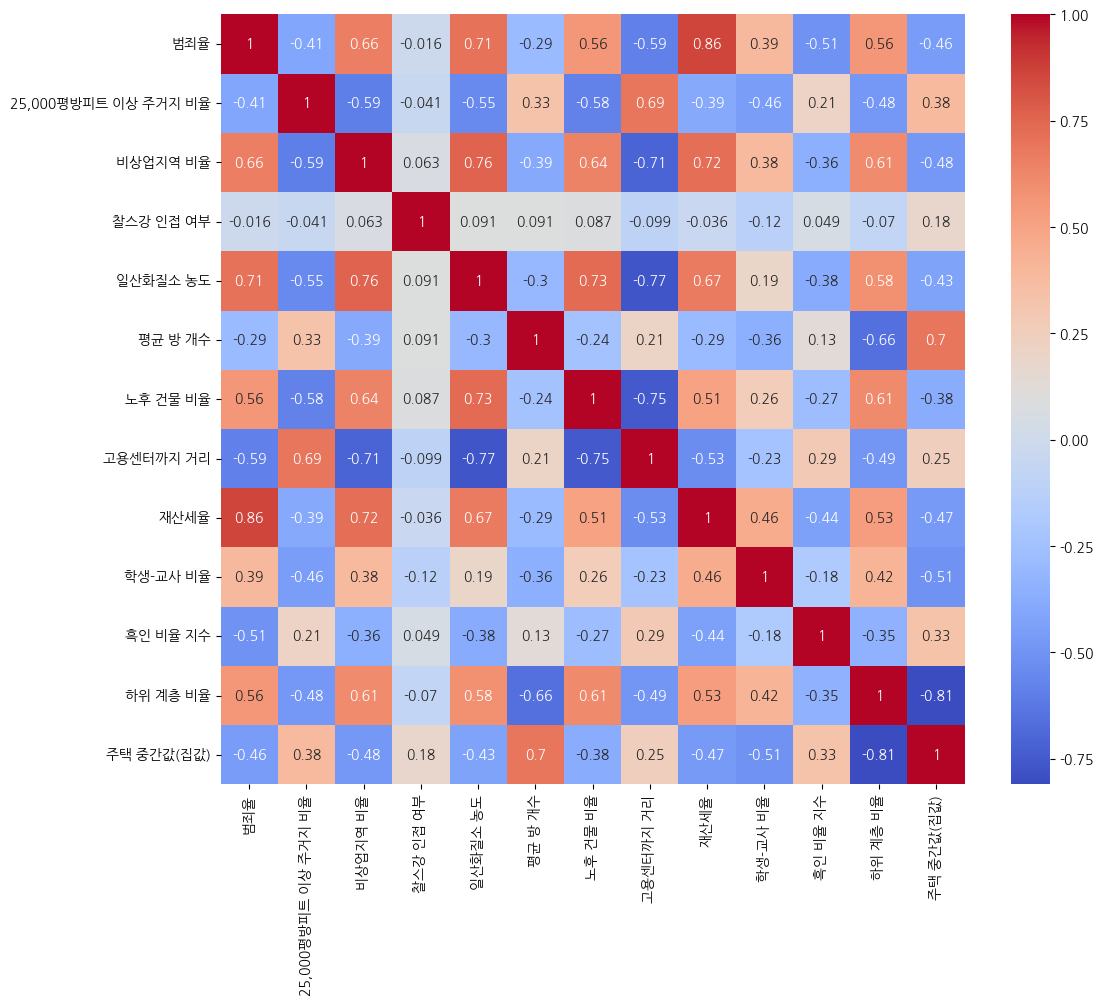

In [12]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

In [11]:
# 상관관계 
# 인사이트
# 고속도로와 재산세율은 서로 강한 상관관계이므로 다중공선성문제가 있다 해결을위해 집값과 상관관계가 적은 고속도로 접근성을 삭제했습니다.
# 하위 계층 비율 은 강한 음의 관계로 하위계층 비율이 높을수록 집값은 낮아집니다.
# 평균 방 개수는 강한 양의 상관관계로 방개수가 늘수록 집값은 상승합니다.


df.drop(columns=['고속도로 접근성'], inplace=True)

# 핵심 컬럼
# 하위계층비율 / 평균 방 개수


이변량 분석 변수별 관계 분석

In [ ]:
# 1. 하위계층비율 ↔ 주택 중간값(집값)
# 2. 평균 방 개수 ↔ 주택 중간값(집값)/방개수등급 범주형
# 3. 범죄율 ↔ 주택 중간값(집값)
# 4. 학생-교사 비율 ↔ 주택 중간값(집값)
# 5. 25,000평방피트 이상 주거지 비율 ↔ 주택 중간값(집값)

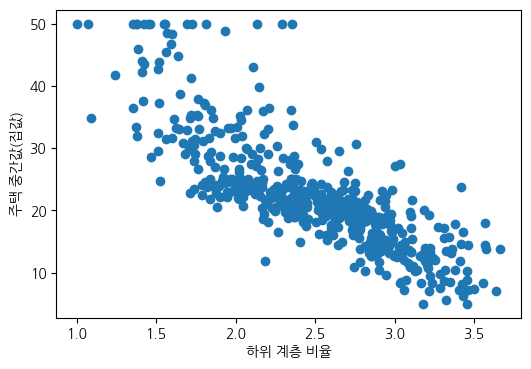

In [13]:
# 1. 하위 계층 비율 ↔ 주택 중간값(집값)
plt.figure(figsize=(6,4))
plt.scatter(df["하위 계층 비율"], df["주택 중간값(집값)"])
plt.xlabel("하위 계층 비율")
plt.ylabel("주택 중간값(집값)")
plt.show()

# 분석 
# 하위 계층 비율이 높을 수록 집값이 낮은 분포를 많이 확인할수있다
# 반대로 하위계층 비율이 적을 수록 주택값이 높아지는걸 확인할수있다
# 가장 데이터 밀집도가 높은곳은 하위계층비율 0.80 ~ 0.90 에서 주택 중간값(집값) 10 ~ 30 구간으로 확인된다
# 산점도에서 하위 계층 비율이 증가할수록 주택 중간값이 감소하는 음의 상관관계가 나타났다

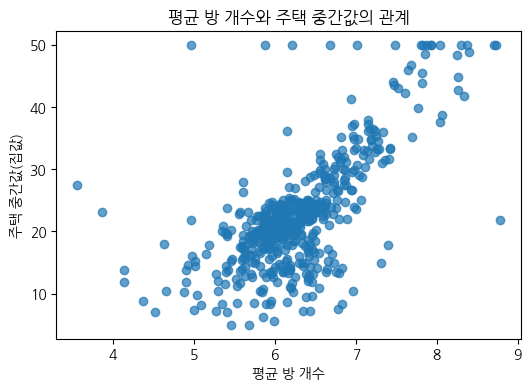

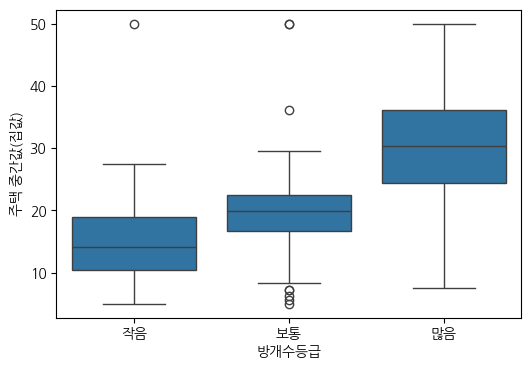

In [14]:
# 2. 평균 방 개수 ↔ 주택 중간값(집값)/방크기등급 범주형
plt.figure(figsize=(6,4))
plt.scatter(df["평균 방 개수"], df["주택 중간값(집값)"], alpha=0.7)

plt.xlabel("평균 방 개수")
plt.ylabel("주택 중간값(집값)")
plt.title("평균 방 개수와 주택 중간값의 관계")

plt.show()
plt.figure(figsize=(6,4))
sns.boxplot(x="방개수등급", y="주택 중간값(집값)", data=df)

plt.xlabel("방개수등급")
plt.ylabel("주택 중간값(집값)")
plt.show()

# 분석
# 가장 많은 데이터가 분포된곳은 평균방 5~7 주택 중간값(집값) 10~ 20 이다
# 방개수가 높을수록 집값도 높아지는걸 산점도를 통해 확인할수있다. 양의 상관관계이다
# 박스플롯을 통해 방 개수가 작음에서 보통 많음 으로 넘어갈수록 집값에 중간값이 높아지는걸확인할수있다
# 특히 방이 많을때 주택 가격의 최소값 최대값에 범위가 넓다 / 방개수가 보통일때 집값이 매우 저렴하거나 매우 높은 이상치들이 많이 확인된다

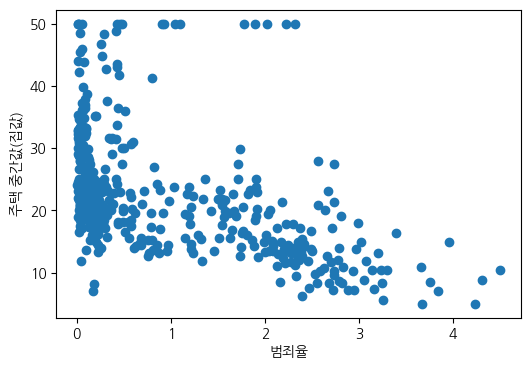

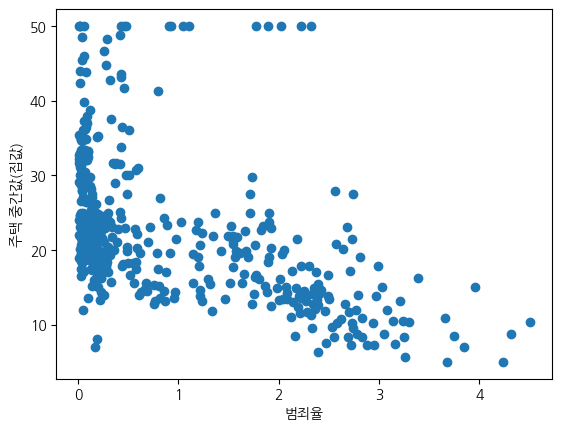

In [15]:
# 3. 범죄율 ↔ 주택 중간값(집값)

plt.figure(figsize=(6,4))
plt.scatter(df["범죄율"], df["주택 중간값(집값)"])
plt.xlabel("범죄율")
plt.ylabel("주택 중간값(집값)")
plt.show()

# 분석plt.figure(figsize=(6,4))
plt.scatter(df["범죄율"], df["주택 중간값(집값)"])
plt.xlabel("범죄율")
plt.ylabel("주택 중간값(집값)")
plt.show()
# 데이터가 두곳이 밀집되어있는걸 확인할수있다.
# 범죄율이 없거나 적은구간은 집값에 분포가 20~ 30에 밀집되어있다
# 범죄율이 높은곳은 집값이 10~20 으로 집값이 낮은 곳으로 확인된다
# 빈곤층이 거주할것으로 예상되는 집값이 낮은지역에 범죄율이 높다는걸 확인할수있다.

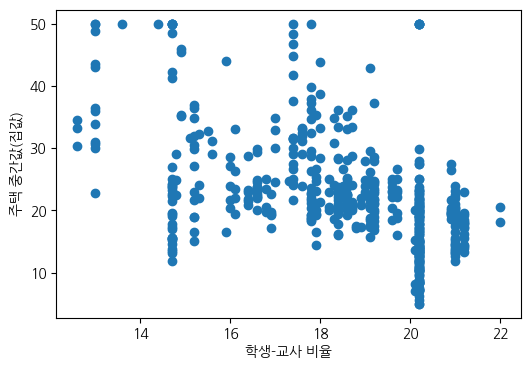

In [16]:
# 4. 학생-교사 비율 ↔ 주택 중간값(집값)

plt.figure(figsize=(6,4))
plt.scatter(df["학생-교사 비율"], df["주택 중간값(집값)"])
plt.xlabel("학생-교사 비율")
plt.ylabel("주택 중간값(집값)")
plt.show()

# 분석
# 교사와 학생 비율이 높은 18~ 22 구간은 집값이 낮은곳에 데이터가 분포되어있다
#  반대로 학생과 교사 비율이 5~ 18 되는 구간에는 집값이 높게 분포되어있다 
# 특히 학생교사 비율 18이하에 집값이 40~50 높은 데이터가 많은걸 확인할수있다
# 집값과 교육조건은 관계가 있다

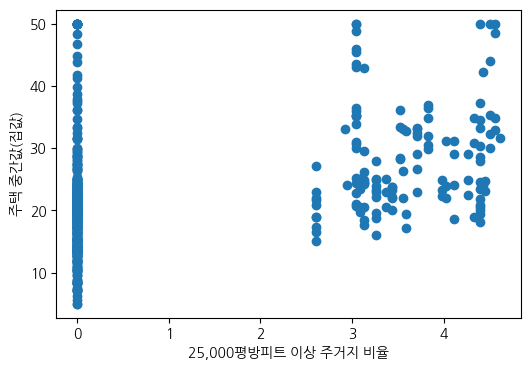

In [17]:
# 5. 25,000평방피트 이상 주거지 비율 ↔ 주택 중간값(집값)

plt.figure(figsize=(6,4))
plt.scatter(df["25,000평방피트 이상 주거지 비율"], df["주택 중간값(집값)"])
plt.xlabel("25,000평방피트 이상 주거지 비율")
plt.ylabel("주택 중간값(집값)")
plt.show()

# 분석
# 주거지 비율이 대형인것과 아닌것은 집값에 큰영향은 없다


In [18]:
# 최종 인사이트


# 주거지 비율이 대형인것 아닌것에 집값에 큰 관계는 없다.
# 학생교사 비율이 낮을수록 집값이 높은 경향을 보여 학생교사 비율과 집값은 음의 상관관계를 보였다.
# 범죄율이 높은 지역일수록 집값이 낮은 경향을 보였으며, 범죄율과 집값은 음의 상관관계를 나타냈다.
# 하위계층비율은 주택가격에 큰 음의 상관관계가있다 하위계층일수록 주택가격이 낮은것으로 확인된다.
# 방개수가 많을수록 집값은 높은것으로 확인되고 특이한 사항은 방개수가 많은 집들은 집값 분포 범위가 넓게 나타나 다양한 가격대를 형성하고있다.

# 집값에 가장 큰 관계가있는 변수는 방 개수와 하위계층비율인것을 확인하였다.